In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
words = open('/content/names.txt','r').read().splitlines()
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [ ]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [ ]:
import random
random.seed(42)
random.shuffle(words)

block_size = 3
def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    return torch.tensor(X), torch.tensor(Y)

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xval, Yval = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [ ]:
Xtr.shape, Ytr.shape

(torch.Size([182625, 3]), torch.Size([182625]))

In [ ]:
n_embed = 10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size,n_embed), generator=g)
W1 = torch.randn((n_embed*block_size,n_hidden),generator=g) * (5/3 / (n_embed*block_size)**0.5)
b1 = torch.randn(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden,vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0

bngain = torch.ones((1,n_hidden))
bnbias = torch.zeros((1,n_hidden))
bnmean_running = torch.zeros((1,n_hidden))
bnstd_running = torch.ones((1,n_hidden))
parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True

12297


In [ ]:
from functools import lru_cache
num_iter = 200000
batch_size = 32
losses = []
for i in range(num_iter):
  #minibatch
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix]

  #forward pass
  emb = C[Xb]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 + b1
  bnmeani = hpreact.mean(0,keepdim=True)
  bnstdi = hpreact.std(0,keepdim=True)
  hpreact = bngain * (hpreact-bnmeani) / bnstdi + bnbias

  with torch.no_grad():
    bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
    bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi

  h = torch.tanh(hpreact)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, Yb)

  #backward pass
  for p in parameters:
    p.grad = None

  loss.backward()


  #update parameters
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad
  if(i%10000 == 0):
    print(f'{i}: {loss.item()}')
  losses.append(loss.log10().item())

0: 3.3113555908203125
10000: 2.514777660369873
20000: 2.24562668800354
30000: 2.3374392986297607
40000: 2.2601821422576904
50000: 2.2878458499908447
60000: 1.9718753099441528
70000: 2.3239588737487793
80000: 2.0514678955078125
90000: 2.1865172386169434
100000: 2.093175172805786
110000: 1.9707266092300415
120000: 2.1469027996063232
130000: 1.8900988101959229
140000: 1.8337063789367676
150000: 2.1132686138153076
160000: 1.9945704936981201
170000: 2.0733115673065186
180000: 2.0938796997070312
190000: 1.7962887287139893


tensor(-0.0013) tensor(1.0132)
tensor(0.0074) tensor(3.1914)


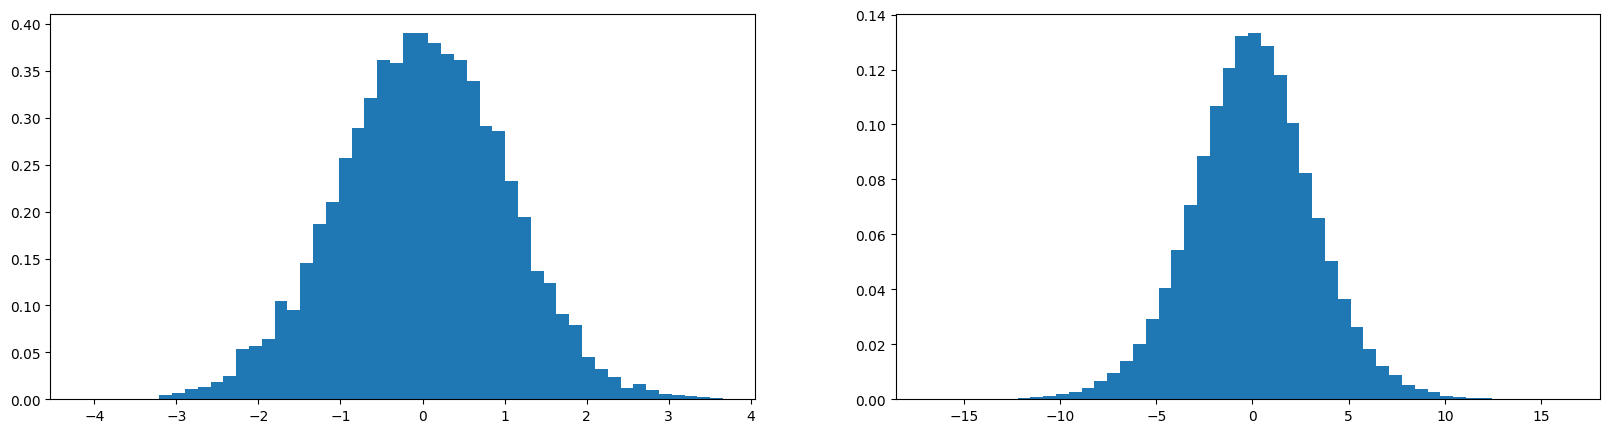

In [ ]:
x = torch.randn(1000, 10)
w = torch.randn(10, 200)
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())
plt.figure(figsize=(20,5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True);
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density=True);

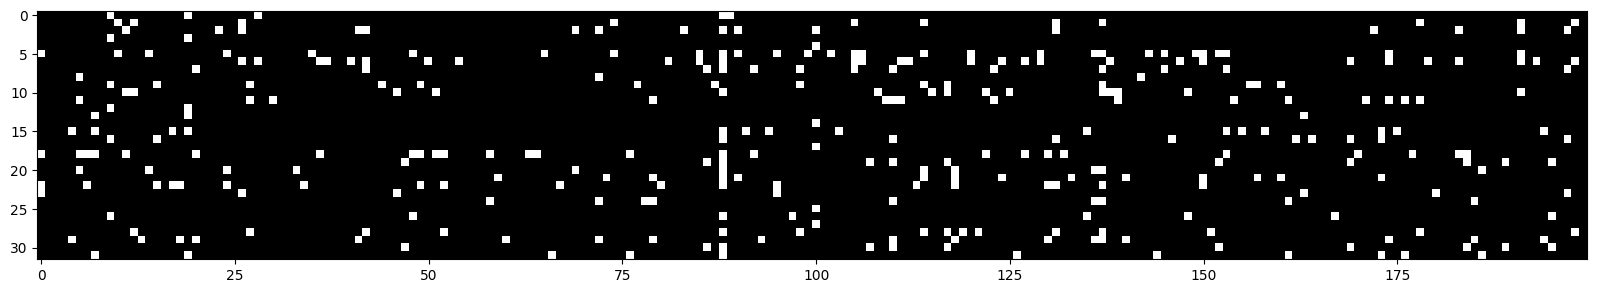

In [ ]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

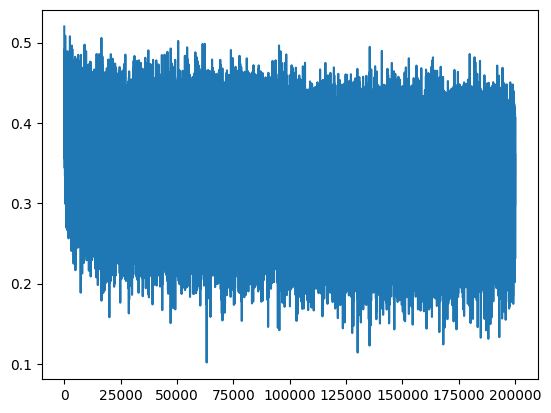

In [ ]:
plt.plot(losses)

In [ ]:
with torch.no_grad():
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 + b1

  bnmean = hpreact.mean(0, keepdim=True)
  bnstd = hpreact.std(0, keepdim=True)


In [ ]:
bnmean

tensor([[-2.6410e+00, -4.7074e-01, -2.7489e-01,  8.7784e-01,  7.5181e-01,
          5.8671e-01,  2.7475e+00, -1.3786e+00,  9.2649e-01,  1.2136e+00,
         -1.3297e+00, -2.6750e+00, -1.1632e+00,  1.5726e-01, -1.6880e-01,
         -3.3734e-01,  1.1756e+00, -2.4883e+00, -1.0005e+00,  1.3145e+00,
         -5.6894e-01,  8.1957e-03, -5.8887e-01,  3.1058e-01,  1.7410e+00,
          3.8714e-02,  1.1479e+00,  5.6533e-01,  4.7921e-01,  1.5115e+00,
         -4.2939e-02, -1.5218e+00,  5.5269e-01,  2.5567e-01, -2.4550e-01,
         -1.4009e+00,  4.1482e-01,  2.9415e-02, -1.0205e-01,  5.4183e-01,
         -3.5626e-01, -1.1390e+00, -6.8388e-01,  2.1615e-01,  1.0328e+00,
          2.3948e-01,  1.9906e+00, -1.3289e+00,  2.3807e+00,  1.4220e+00,
          1.5491e+00,  4.0285e-01,  1.4246e+00,  8.3179e-01,  1.1438e+00,
         -2.7236e+00, -6.3571e-02,  6.1970e-02,  1.6204e+00, -1.0706e+00,
         -3.3817e-01,  1.1442e+00,  2.3853e-01,  5.2132e-01,  1.7949e+00,
          1.7007e+00, -6.2496e-01,  1.

In [ ]:
bnmean_running

tensor([[-2.6313, -0.4820, -0.2640,  0.8726,  0.7496,  0.5734,  2.7503, -1.3833,
          0.9308,  1.2198, -1.3272, -2.6606, -1.1563,  0.1601, -0.1716, -0.3443,
          1.1801, -2.4810, -0.9901,  1.3051, -0.5637, -0.0069, -0.6044,  0.3067,
          1.7357,  0.0297,  1.1451,  0.5568,  0.4723,  1.5082, -0.0405, -1.5304,
          0.5570,  0.2685, -0.2493, -1.3989,  0.4264,  0.0183, -0.1113,  0.5372,
         -0.3394, -1.1339, -0.6760,  0.2135,  1.0290,  0.2306,  1.9933, -1.3114,
          2.3713,  1.4253,  1.5453,  0.4050,  1.4317,  0.8292,  1.1579, -2.7055,
         -0.0732,  0.0546,  1.6126, -1.0489, -0.3323,  1.1424,  0.2163,  0.5161,
          1.7921,  1.6888, -0.6090,  1.1036, -1.1766, -0.4841, -0.0583,  0.3762,
          1.3083, -0.3281, -2.6276,  0.4350,  1.1760, -0.5419,  0.1727,  0.1865,
          0.0350,  1.2087,  1.5470,  0.9104,  1.1937, -0.3574, -0.3169, -0.0857,
          2.4058, -0.5396, -1.2372,  1.0805, -1.2110, -1.1435, -1.1908,  0.6627,
          0.1830, -1.0675,  

In [ ]:
@torch.no_grad()

def split_loss(split):
  x, y = {
      'train': (Xtr, Ytr),
      'val': (Xval, Yval),
      'test': (Xte, Yte),
  }[split]

  emb = C[x]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 + b1
  hpreact = bngain * (hpreact-bnmean) / bnstd + bnbias
  h = torch.tanh(hpreact)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits,y)
  print(loss)

split_loss('val')
split_loss('test')



tensor(2.1075)
tensor(2.1056)


In [ ]:
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break

    print(''.join(itos[i] for i in out))

carlahnabbbllsahbirrixzeptcanncarlayselhnevfahnslyttl.
quicpelmarrichniah.
prishkph.
blakshm.
quinton.
ldveriyah.
quiqaeghniqarhsimfixhzphusdbeefffrogabeth.
fnykarrahpastivlreksyahnmelos.
zekthejn.
pastieghnnypoladlbuhdionyer.
praakrynpencyalhanrayveten.
boobriyah.
vayapzerustmfovamsldegpylniyah.
kkmcrrdrzonyeadhk.
khlesdan.
kzametevfryd.
qswlonyeonb.
krishnnahmarlazzallyzsh.
phxell.
bnizervssebic.


In [ ]:
-torch.tensor(1/27.0).log()

tensor(3.2958)

## Torchify NN

In [ ]:
class Linear:
  def __init__(self, fanin, fanout, bias=True):
    self.weight = torch.randn((fanin, fanout), generator=g) / fanin**0.5
    self.bias = torch.zeros(fanout) if bias else None

  def __call__(self,x): #input*weight + bias
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias is None else [self.bias]])



class BatchNorm1D:
